In [22]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/rf
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [30]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge**2 / (4 * mass * Omega**2)

In [31]:
from post_processing import read_post_processed

x, y, z, potentials = read_post_processed(filename="rf_sim_out.h5", electrode_names=[13])

In [32]:
Ex, Ey, Ez = np.gradient(-potentials[13], x[:, 0, 0], y[0, :, 0], z[0, 0, :], edge_order=2)
pseudo_potential = pseudo_factor * (Ex**2 + Ey**2 + Ez**2)

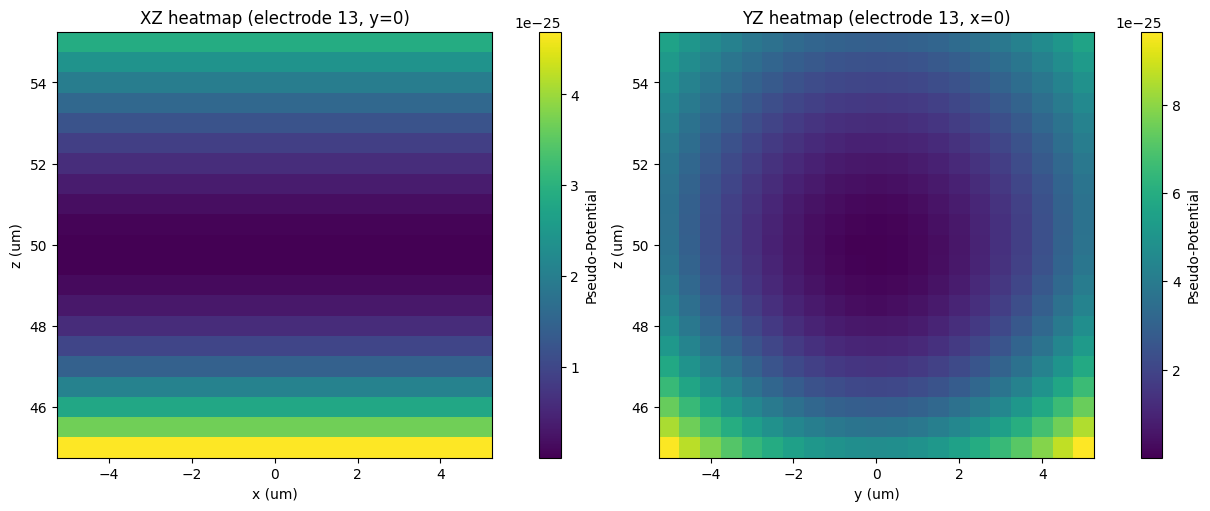

In [42]:
phi = pseudo_potential

# Choose central slices (or closest to 0 if available).
x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]

x_idx = int(np.argmin(np.abs(x_axis - 0.0))) if np.any(np.isfinite(x_axis)) else x.shape[0] // 2
y_idx = int(np.argmin(np.abs(y_axis - 0.0))) if np.any(np.isfinite(y_axis)) else y.shape[1] // 2

# xz slice at fixed y
X_xz = x[:, y_idx, :]
Z_xz = z[:, y_idx, :]
P_xz = phi[:, y_idx, :]

# yz slice at fixed x
Y_yz = y[x_idx, :, :]
Z_yz = z[x_idx, :, :]
P_yz = phi[x_idx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

hm1 = axes[0].pcolormesh(X_xz*1e6, Z_xz*1e6, P_xz, shading="auto", cmap="viridis")
axes[0].set_title(f"XZ heatmap (electrode {electrode}, y={y_axis[y_idx]*1e6:.4g})")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("z (um)")
fig.colorbar(hm1, ax=axes[0], label="Pseudo-Potential")

hm2 = axes[1].pcolormesh(Y_yz*1e6, Z_yz*1e6, P_yz, shading="auto", cmap="viridis")
axes[1].set_title(f"YZ heatmap (electrode {electrode}, x={x_axis[x_idx]*1e6:.4g})")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("z (um)")
fig.colorbar(hm2, ax=axes[1], label="Pseudo-Potential")

plt.show()

In [50]:
ion_height_index = np.argmin(pseudo_potential[0, 0, :])
ion_height_ansatz = z[0, 0, ion_height_index]  # Assuming ion is near the center of the trap
x_center_index = np.argmin(np.abs(x_axis - 0.0)) if np.any(np.isfinite(x_axis)) else x.shape[0] // 2
y_center_index = np.argmin(np.abs(y_axis - 0.0)) if np.any(np.isfinite(y_axis)) else y.shape[1] // 2

Text(0, 0.5, 'Pseudo-Potential')

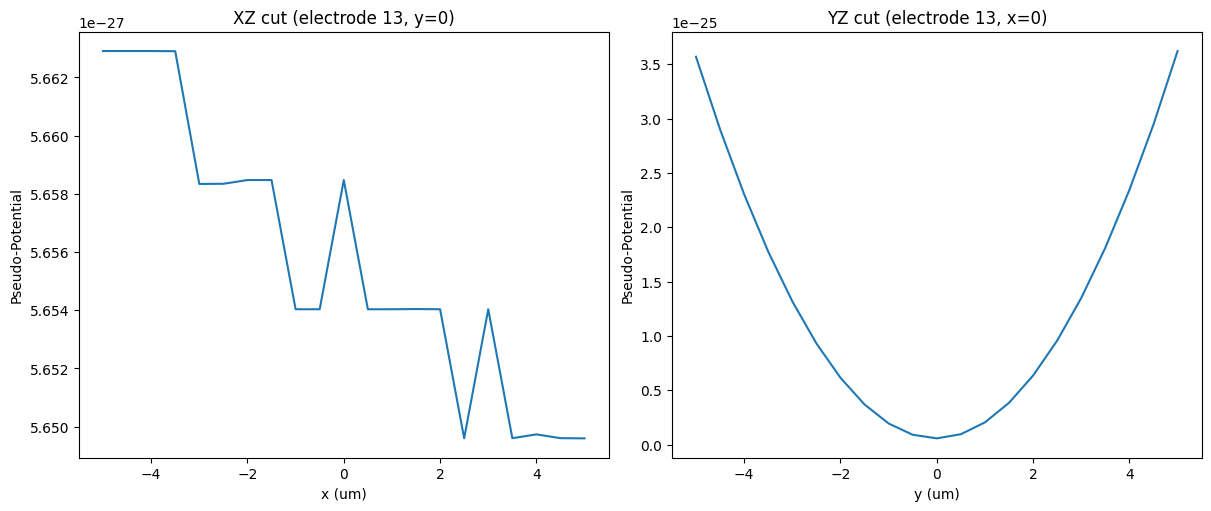

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axes[0].plot(x[:, y_center_index, ion_height_index]*1e6, pseudo_potential[:, y_center_index, ion_height_index])
axes[0].set_title(f"XZ cut (electrode {electrode}, y={y_axis[y_center_index]*1e6:.4g})")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("Pseudo-Potential")

axes[1].plot(y[x_center_index, :, ion_height_index]*1e6, pseudo_potential[x_center_index, :, ion_height_index])
axes[1].set_title(f"YZ cut (electrode {electrode}, x={x_axis[x_center_index]*1e6:.4g})")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("Pseudo-Potential")

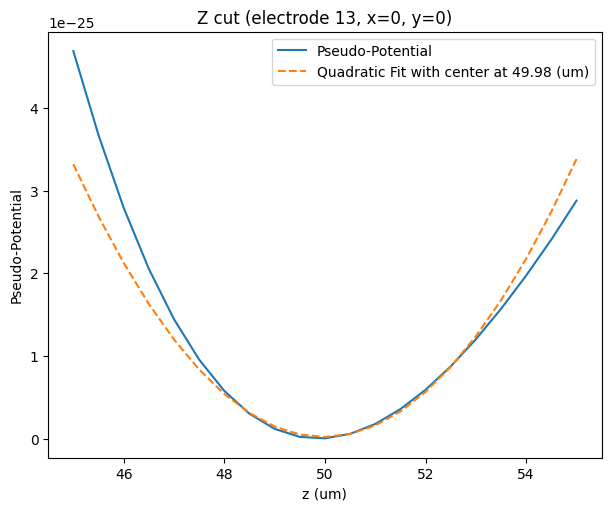

In [ ]:
phi_z = pseudo_potential[x_center_index, y_center_index, :]
z_vals = z[0, 0, :]
zmin = ion_height_ansatz
window = 2.5e-6  # 2.5 microns around the ion height
mask = np.abs(z_vals - zmin) <= window

coeff = np.polyfit(z_vals[mask], phi_z[mask], 2)
a, b, c = coeff

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.plot(z_vals*1e6, phi_z, label="Pseudo-Potential")
ax.plot(z_vals*1e6, a*z_vals**2 + b*z_vals + c, label=f"Quadratic Fit with center at {-b/(2*a)*1e6:.4g} (um)", linestyle="--")
ax.set_title(f"Z cut (electrode {electrode}, x={x_axis[x_center_index]*1e6:.4g}, y={y_axis[y_center_index]*1e6:.4g})")
ax.set_xlabel("z (um)")
ax.set_ylabel("Pseudo-Potential")
ax.legend()
plt.show()